# Titanic 

### Load Data

In [33]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns


df = sns.load_dataset("titanic")

### Data Preprocessing

In [34]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [35]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [36]:
df['age'] = df['age'].fillna(df['age'].mean())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])


In [37]:
df = df.drop(["deck", "embark_town", "class", "who", "alive"], axis=1)

In [38]:
cols = ["embarked", "sex"]
df = pd.get_dummies(df, columns=cols, drop_first=True)

In [39]:
# Target variable
print(df["survived"].value_counts())

# Percentage distribution
print(df["survived"].value_counts(normalize=True) * 100)

survived
0    549
1    342
Name: count, dtype: int64
survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


### Train-test split

In [40]:
from sklearn.model_selection import train_test_split

X = df.drop("survived", axis=1)
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Feature Scaling

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Imbalanced Data Handling

In [42]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

### Train model

In [59]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

model.fit(X_res, y_res)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[: ,1]

### Evaluation

In [60]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8044692737430168
Precision: 0.7532467532467533
Recall: 0.7837837837837838
F1 Score: 0.7682119205298014

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.82      0.83       105
           1       0.75      0.78      0.77        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.80      0.80       179



### Confusion Matrix

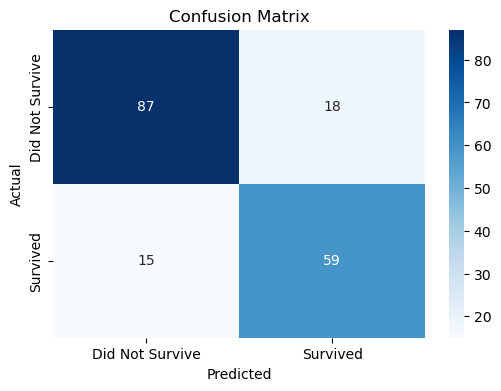

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Visualisation

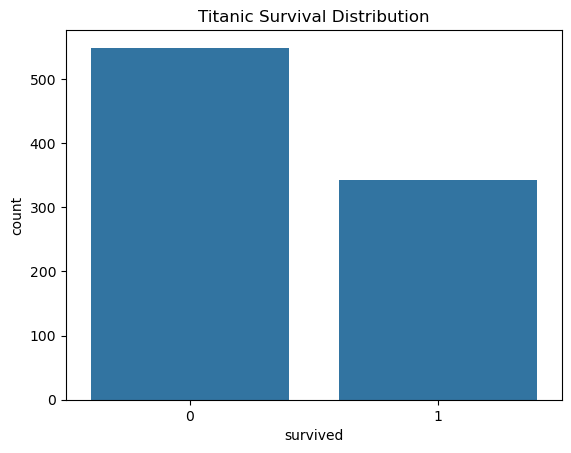

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="survived")
plt.title("Titanic Survival Distribution")
plt.show()

In [ ]:
### 

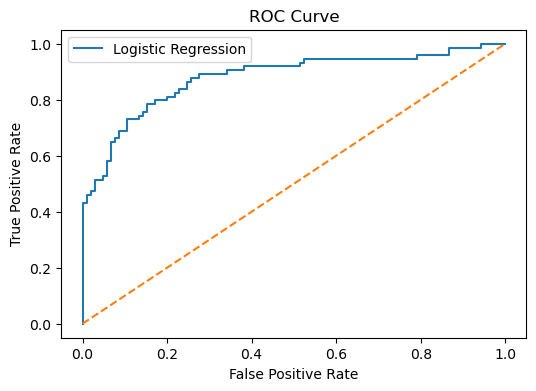

In [51]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [52]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc)

AUC Score: 0.879021879021879


In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Model
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

# Hyperparameter grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

# Grid Search
grid = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train, y_train)

,estimator,LogisticRegre...max_iter=1000)
,param_grid,"{'C': [0.001, 0.01, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'
